## Exploratory Data Analysis (EDA)

In [2]:
import sys
!{sys.executable} -m pip install -q \
    pandas numpy \
    matplotlib seaborn tqdm 
print("All packages installed.")

All packages installed.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.notebook import tqdm

print("Imports OK.")

Imports OK.


In [7]:
DATA_PATH = "data/movies.csv"
df = pd.read_csv(DATA_PATH)

In [8]:
df.head()

,id,title,year,genres,vote_average,vote_count,popularity,runtime,director,cast,overview,original_language
0,83533,Avatar: Fire and Ash,2025,"Science Fiction, Adventure, Fantasy",7.4,2391,485.10,198,James Cameron,"Sam Worthington, Zoe Saldaña, Sigourney Weaver...",In the wake of the devastating war against the...,en
1,1327819,Hoppers,2026,"Animation, Family, Science Fiction, Comedy, Ad...",7.6,395,395.36,105,Daniel Chong,"Piper Curda, Bobby Moynihan, Jon Hamm, Kathy N...",Scientists have discovered how to 'hop' human ...,en
2,1171145,Crime 101,2026,"Crime, Thriller",7.1,516,339.60,141,Bart Layton,"Chris Hemsworth, Mark Ruffalo, Halle Berry, Ba...",When an elusive thief whose high-stakes heists...,en
3,1115544,Mike & Nick & Nick & Alice,2026,"Comedy, Science Fiction, Crime",6.8,178,301.23,107,BenDavid Grabinski,"James Marsden, Vince Vaughn, Eiza González, Ke...",Two gangsters and the woman they love try to s...,en
4,1290821,Shelter,2026,"Action, Crime, Thriller",6.8,489,326.12,107,Ric Roman Waugh,"Jason Statham, Bodhi Rae Breathnach, Michael S...",A man living in self-imposed exile on a remote...,en


### Rating Distribution

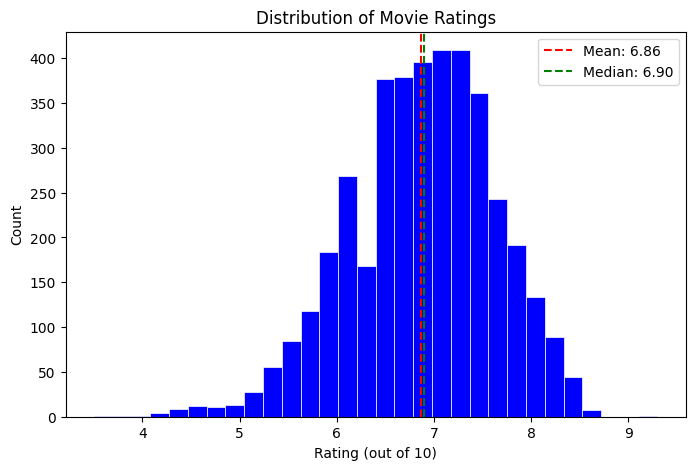

In [9]:
fig, ax = plt.subplots(figsize=(8, 5)) 

# histograph
ax.hist(df["vote_average"].dropna(), bins=30, color="blue", edgecolor="white", linewidth=0.5)
ax.axvline(df["vote_average"].mean(), color="red", linestyle="--", label=f'Mean: {df["vote_average"].mean():.2f}')
ax.axvline(df["vote_average"].median(), color="green", linestyle="--", label=f'Median: {df["vote_average"].median():.2f}')

ax.set_xlabel("Rating (out of 10)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Movie Ratings")
ax.legend()

plt.show()

In [10]:
df['vote_average'].max()

9.3

In [11]:
df.loc[df['vote_average'].idxmax(), 'title'] # highest rated movie

'BTS THE COMEBACK LIVE | ARIRANG'

In [12]:
df['vote_average'].min()

3.5

In [13]:
df.loc[df['vote_average'].idxmin(), 'title'] # lowest rated movie

'Melania'

### Genre Frequency

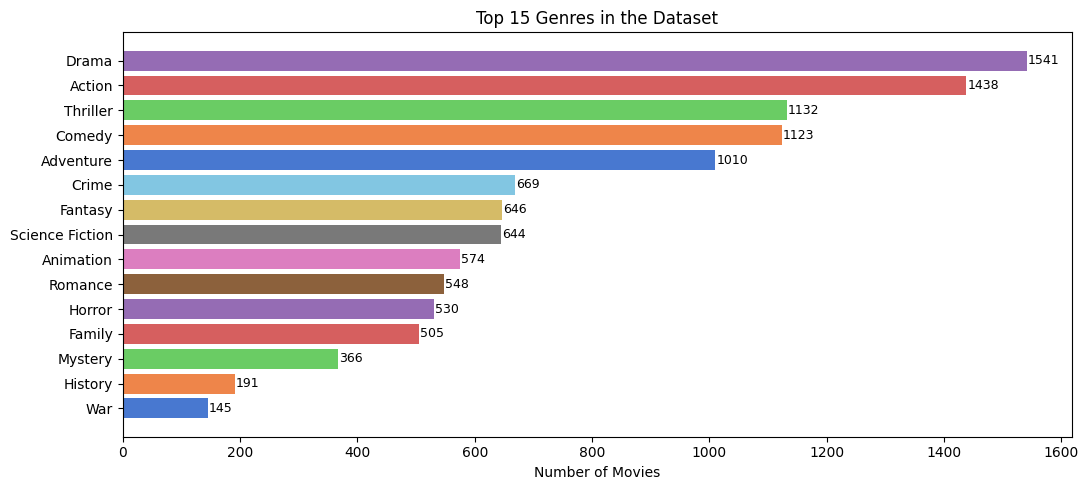

In [14]:
genre_series = df["genres"].dropna().str.split(", ").explode()
genre_counts = genre_series.value_counts()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(genre_counts.index[:15][::-1], genre_counts.values[:15][::-1],
               color=sns.color_palette("muted", 15))
ax.set_xlabel("Number of Movies")
ax.set_title("Top 15 Genres in the Dataset")
for bar, val in zip(bars, genre_counts.values[:15][::-1]):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2, str(val), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("data/genre_distribution.png", bbox_inches="tight")
plt.show()

### Movies by Release Year

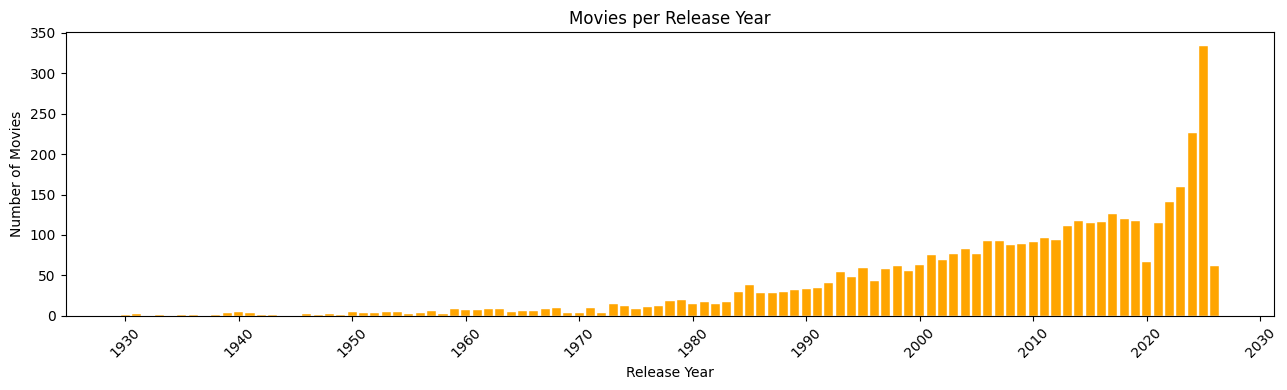

In [15]:
year_counts = df["year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(year_counts.index, year_counts.values, color="orange", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Movies")
ax.set_title("Movies per Release Year")
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("data/year_distribution.png", bbox_inches="tight")
plt.show()

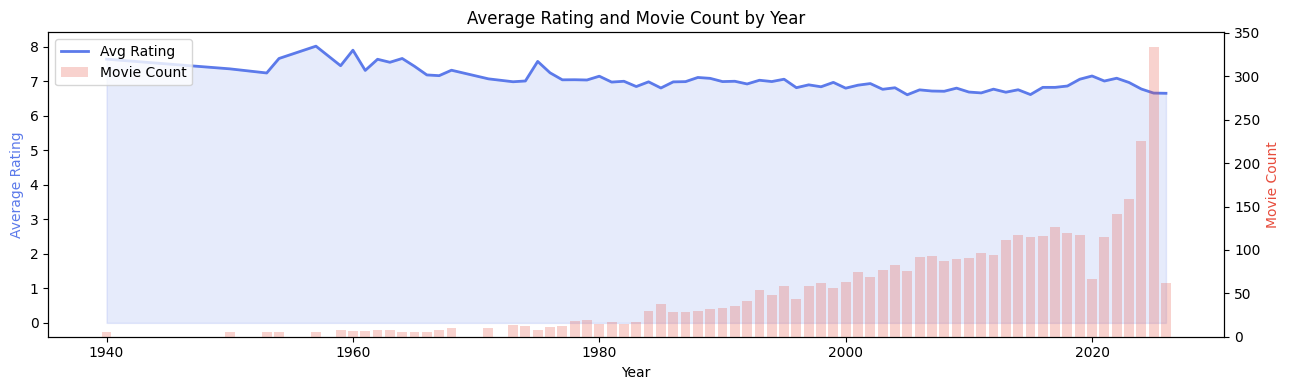

In [16]:
avg_by_year = df.groupby("year")["vote_average"].agg(["mean", "count"])
avg_by_year = avg_by_year[avg_by_year["count"] >= 5]  # only years with enough data

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()

ax1.plot(avg_by_year.index, avg_by_year["mean"], color="#5C7AEA", linewidth=2, label="Avg Rating")
ax1.fill_between(avg_by_year.index, avg_by_year["mean"], alpha=0.15, color="#5C7AEA")
ax2.bar(avg_by_year.index, avg_by_year["count"], alpha=0.25, color="#E74C3C", label="Movie Count")

ax1.set_xlabel("Year")
ax1.set_ylabel("Average Rating", color="#5C7AEA")
ax2.set_ylabel("Movie Count", color="#E74C3C")
ax1.set_title("Average Rating and Movie Count by Year")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.savefig("data/rating_trend.png", bbox_inches="tight")
plt.show()


### Top Directors

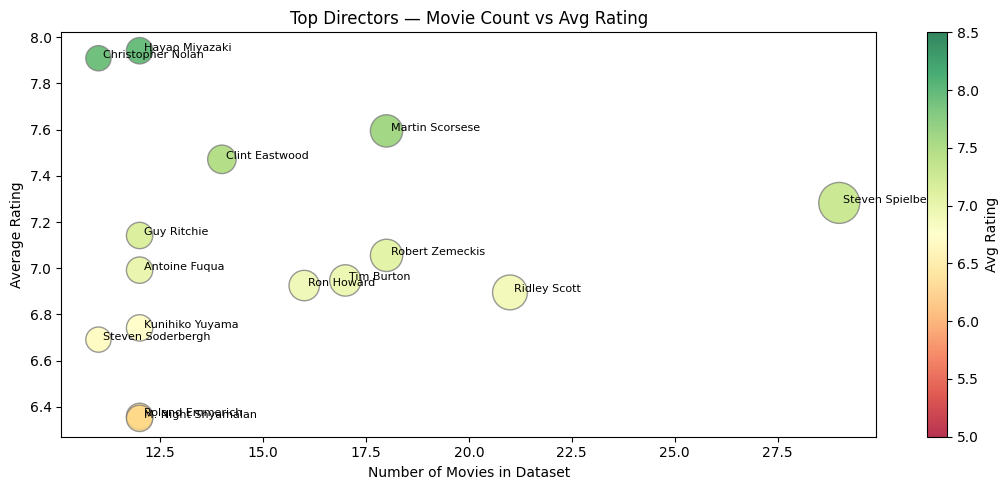

Top 10 directors by movie count:
                  movies  avg_rating
director                            
Steven Spielberg      29    7.282759
Ridley Scott          21    6.895238
Robert Zemeckis       18    7.055556
Martin Scorsese       18    7.594444
Tim Burton            17    6.947059
Ron Howard            16    6.925000
Clint Eastwood        14    7.471429
Hayao Miyazaki        12    7.941667
Antoine Fuqua         12    6.991667
Roland Emmerich       12    6.358333


In [17]:
top_directors = (
    df[df["director"] != ""]
    .groupby("director")
    .agg(movies=("title", "count"), avg_rating=("vote_average", "mean"))
    .query("movies >= 3")
    .sort_values("movies", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(11, 5))
scatter = ax.scatter(
    top_directors["movies"],
    top_directors["avg_rating"],
    s=top_directors["movies"] * 30,
    c=top_directors["avg_rating"],
    cmap="RdYlGn", vmin=5, vmax=8.5, alpha=0.8, edgecolors="grey"
)
for _, row in top_directors.iterrows():
    ax.annotate(row.name, (row["movies"] + 0.1, row["avg_rating"]), fontsize=8)
plt.colorbar(scatter, label="Avg Rating")
ax.set_xlabel("Number of Movies in Dataset")
ax.set_ylabel("Average Rating")
ax.set_title("Top Directors — Movie Count vs Avg Rating")
plt.tight_layout()
plt.savefig("data/top_directors.png", bbox_inches="tight")
plt.show()

print("Top 10 directors by movie count:")
print(top_directors.head(10).to_string())


### Runtime Distribution

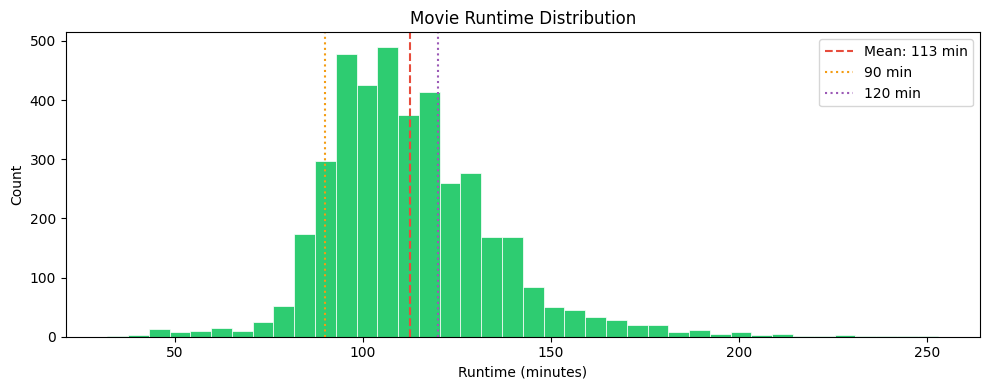

In [18]:
runtime_clean = df["runtime"].dropna()
runtime_clean = runtime_clean[(runtime_clean > 30) & (runtime_clean < 300)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(runtime_clean, bins=40, color="#2ECC71", edgecolor="white", linewidth=0.5)
ax.axvline(runtime_clean.mean(), color="#E74C3C", linestyle="--", label=f"Mean: {runtime_clean.mean():.0f} min")
ax.axvline(90,  color="#F39C12", linestyle=":", label="90 min")
ax.axvline(120, color="#9B59B6", linestyle=":", label="120 min")
ax.set_xlabel("Runtime (minutes)")
ax.set_ylabel("Count")
ax.set_title("Movie Runtime Distribution")
ax.legend()
plt.tight_layout()
plt.savefig("data/runtime_distribution.png", bbox_inches="tight")
plt.show()

### Rating vs Vote Count

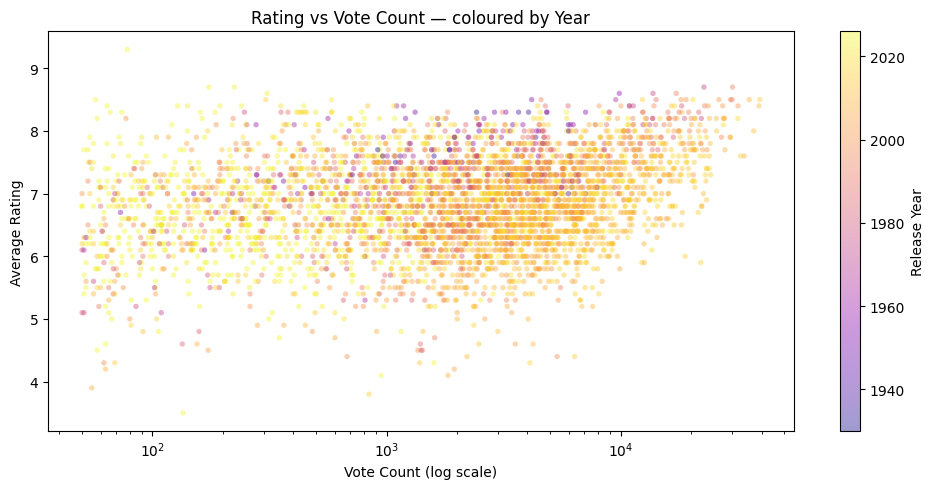

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(
    df["vote_count"], df["vote_average"],
    c=df["year"], cmap="plasma",
    alpha=0.4, s=15, linewidths=0
)
plt.colorbar(sc, label="Release Year")
ax.set_xscale("log")
ax.set_xlabel("Vote Count (log scale)")
ax.set_ylabel("Average Rating")
ax.set_title("Rating vs Vote Count — coloured by Year")
plt.tight_layout()
plt.savefig("data/rating_vs_votes.png", bbox_inches="tight")
plt.show()


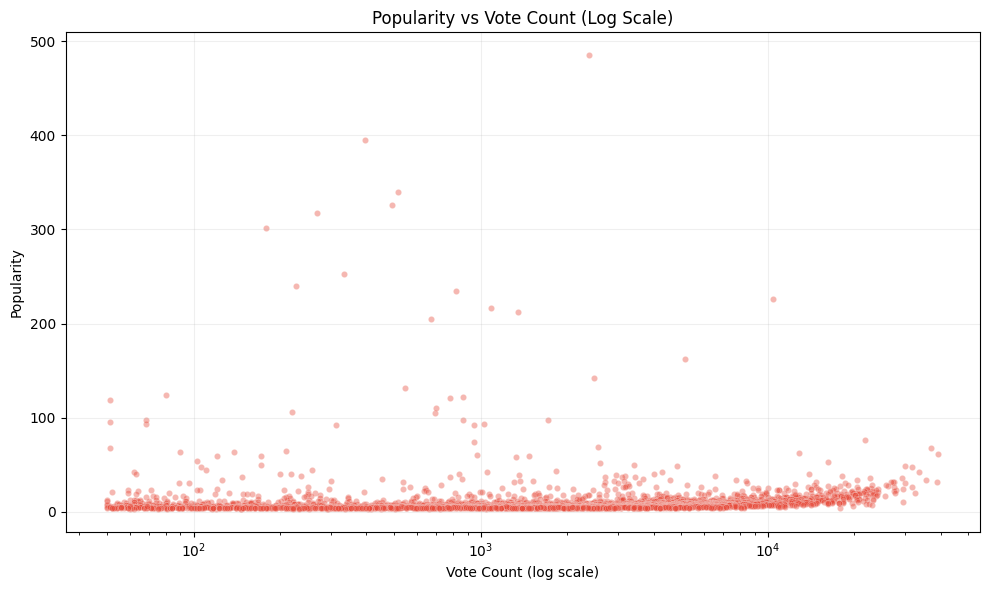

In [20]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["vote_count"],
    df["popularity"],
    alpha=0.4,
    s=20,
    color="#E74C3C",
    edgecolor="white",
    linewidth=0.3
)

plt.xscale("log")
plt.xlabel("Vote Count (log scale)")
plt.ylabel("Popularity")
plt.title("Popularity vs Vote Count (Log Scale)")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

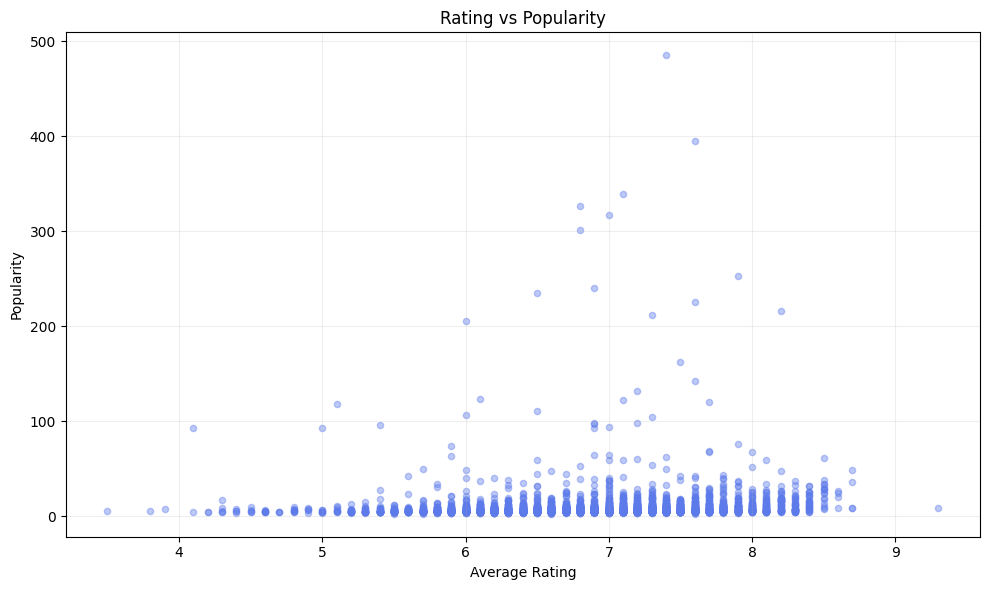

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(df["vote_average"], df["popularity"], alpha=0.4, s=20, color="#5C7AEA")

plt.xlabel("Average Rating")
plt.ylabel("Popularity")
plt.title("Rating vs Popularity")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Thus, no clear relation between popularity and rating and popularity and vote count as well. 

## Data Preprocessing

In [22]:
print(f"Before cleaning: {len(df)} rows")

Before cleaning: 4000 rows


In [23]:
# drop rows missing critical fields

df = df.dropna(subset=["title", "year", "genres"]) # if the row is missing any of these, drop it
df = df[df["overview"].str.len() > 20] # if the overview is longer than 20 characters, keep it
df = df[df["genres"].str.len() > 0] # if the genre of the film is missing, drop it

In [24]:
# type coercions - forces a 'bad value' to NaN (Not a Number), then converts to a certain type
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["vote_average"] = pd.to_numeric(df["vote_average"], errors="coerce").fillna(0.0)
df["vote_count"] = pd.to_numeric(df["vote_count"], errors="coerce").fillna(0).astype(int)
df["runtime"] = pd.to_numeric(df["runtime"], errors="coerce")

In [25]:
# filling missing text fields (fields which were not dropped in case of missing values)
df["director"] = df["director"].fillna("").str.strip()
df["cast"] = df["cast"].fillna("").str.strip()
df["overview"] = df["overview"].fillna("").str.strip()

In [26]:
df = df.drop_duplicates(subset=["id"]).reset_index(drop=True)

In [27]:
# save cleaned version
df.to_csv(DATA_PATH, index=False)
print(f"After cleaning:  {len(df)} rows")
df[["title","year","genres","vote_average","director","runtime"]].head(8)

After cleaning:  4000 rows


,title,year,genres,vote_average,director,runtime
0,Avatar: Fire and Ash,2025,"Science Fiction, Adventure, Fantasy",7.4,James Cameron,198
1,Hoppers,2026,"Animation, Family, Science Fiction, Comedy, Ad...",7.6,Daniel Chong,105
2,Crime 101,2026,"Crime, Thriller",7.1,Bart Layton,141
3,Mike & Nick & Nick & Alice,2026,"Comedy, Science Fiction, Crime",6.8,BenDavid Grabinski,107
4,Shelter,2026,"Action, Crime, Thriller",6.8,Ric Roman Waugh,107
5,The Super Mario Galaxy Movie,2026,"Animation, Adventure, Fantasy, Family, Comedy",7.0,Michael Jelenic,98
6,Pretty Lethal,2026,"Music, Thriller, Action, Horror",6.9,Vicky Jewson,89
7,GOAT,2026,"Animation, Comedy, Family",7.9,Tyree Dillihay,100


In [28]:
df['title'].nunique()

3890

In [29]:
df['title'].duplicated().sum() 

110

In [30]:
duplicate_count = df.duplicated(subset=['title', 'director', 'year']).sum()
duplicate_count

0

There are 110 movies whose titles are not unique.  
But none of their directors or year of release matches.  
So they are different movies with same title.

In [31]:
print(f"\nYear range: {df['year'].min()} – {df['year'].max()}")
print(f"Rating range: {df['vote_average'].min()} – {df['vote_average'].max()}")
print(f"Unique genres: {df['genres'].str.split(', ').explode().nunique()}")
print(f"Unique directors: {df['director'][df['director']!=''].nunique()}")


Year range: 1930 – 2026
Rating range: 3.5 – 9.3
Unique genres: 19
Unique directors: 1985
